Structure of data:

- complex (ligand and protein):  Data/bh/pdb1bh2.ent.gz
- protein pocket:  Data/bh/1bh2_0_GSP_pocket.pdb
- ligand:  Data/bh/1bh2_0_GSP_ligand.pdb


[16:17:50] WARNING: More than one matching pattern found - picking one



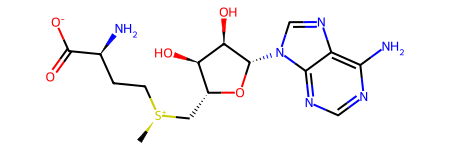

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd

def get_residue_names(pdb_path):
    # 1. 从 PDB 加载分子
    mol = Chem.MolFromPDBFile(pdb_path)
    if mol is None:
        return []

    # 2. 遍历原子并提取残留基名称
    residue_names = set()
    for atom in mol.GetAtoms():
        # 获取 PDB 残留基信息对象
        info = atom.GetPDBResidueInfo()
        if info:
            # 提取名称（例如 "LIG", "DRG", "UNL" 等）
            res_name = info.GetResidueName().strip()
            residue_names.add(res_name)
    
    return list(residue_names)

def create_correct_mol(pdb_path, smiles):
    """
    使用 SMILES 模板修正 PDB 分子的键级信息
    """
    # 1. 加载包含正确键级的模板分子 (来自 SMILES)
    template = Chem.MolFromSmiles(smiles)
    if template is None:
        raise ValueError("无效的 SMILES 字符串")

    # 2. 从 PDB 加载带坐标的分子 (RDKit 默认会将 PDB 键级设为单键)
    # removeHs=False 建议保留氢原子以提高匹配精度
    pdb_mol = Chem.MolFromPDBFile(pdb_path, removeHs=False, sanitize=False)
    # print(f"从 PDB 文件加载的分子包含 {pdb_mol.GetNumAtoms()} 个原子")
    if pdb_mol is None:
        raise ValueError("无法读取 PDB 文件")

    try:
        # 3. 核心步骤：将模板的键级映射到 PDB 分子的坐标上
        # 它会根据原子的元素类型和连接关系进行匹配
        new_mol = AllChem.AssignBondOrdersFromTemplate(template, pdb_mol)
        return new_mol
    except ValueError as e:
        print(f"匹配失败，可能是由于原子数目或元素不匹配: {e}")
        return None

def get_canonical_smiles(input_smiles):
    """
    输入任意SMILES，返回Canonical SMILES（无效则返回None）
    """
    # 1. 读入SMILES为RDKit分子对象
    mol = Chem.MolFromSmiles(input_smiles)
    if mol is None:
        print("❌ 无效SMILES")
        return None
    
    # 2. 生成Canonical SMILES（canonical=True为默认值，可显式写出）
    canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
    return canonical_smiles

cpd_id_file = 'Data/Components-smiles-cactvs.smi'  # 小分子名称和 SMILES 的文件路径
df_cpd_id = pd.read_csv(cpd_id_file, sep='\t', header=None, names=['smiles', 'id', 'name']) # 读取文件并指定列名
df_cpd_id = df_cpd_id.set_index('id', inplace=False, drop=False) # 设置索引列


lig_file = "Data/bh/7bhw_1_SAM_ligand.pdb"  # 小分子PDB 文件路径
cpd_id_list = get_residue_names(lig_file)  # 从 PDB 文件中提取残留基名称列表
smi = df_cpd_id.loc[cpd_id_list[0], 'smiles'] # 根据提取的残留基名称在 DataFrame 中查找对应的 SMILES
smi = get_canonical_smiles(smi)  # 转换为 Canonical SMILES
# template_mol = Chem.MolFromSmiles(smi)
# print(f"{template_mol.GetNumAtoms()} atoms in the template molecule from SMILES: {smi}")

mol = create_correct_mol(lig_file, smi) # 使用 SMILES 模板修正 PDB 分子的键级信息
AllChem.Compute2DCoords(mol) # 计算 2D 坐标以便可视化
display(mol) # 显示分子结构


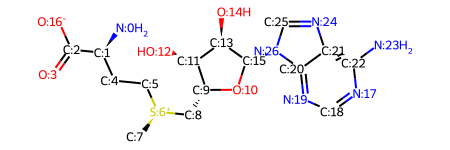

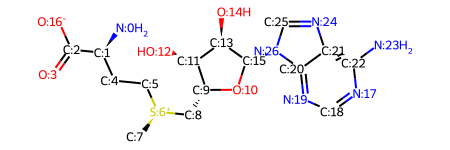

[[0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  24,
  25,
  26],
 [16],
 [0,
  1,
  2,
  3,
  4,
  5,
  6,
  8,
  9,
  10,
  11,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [0,
  1,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 24, 25, 26],
 [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26],
 [17, 18, 19, 20, 21, 22, 24, 25, 26],
 [8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26],
 [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
 

In [13]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
from rdkit.Chem import Draw
from IPython.display import display
import itertools

def frag_mol_near_ring(mol, pos_args={'RR':True, 'nRnR':True}):
    ''' A function to fragmentize molecules via delete the non-ring bond near the ring '''  
    try: 
        # smi='CC(C1=C(C2=CN3C(C(C)=C2)=NC=N3)NC4=CC=C(C5CCN(C(CCO)CCO)CC5)C=C14)C'
        # 2. 获取所有原子 ID（0-based）
        all_atom_ids = [atom.GetIdx() for atom in mol.GetAtoms()]
        if pos_args["nRnR"]:  ## All single bonds except those in ring
            bs=[]
            for bond in mol.GetBonds():
                idx = bond.GetIdx()
                if bond.IsInRing():
                    continue
                btype = bond.GetBondType()
                if btype == Chem.BondType.SINGLE:
                    bs.append(idx)
        else:
            bis = mol.GetSubstructMatches(Chem.MolFromSmarts('[!R][R]'))
            bs = [mol.GetBondBetweenAtoms(x,y).GetIdx() for x,y in bis]
            if pos_args['RR']:  #single bond between two ring
                bis = mol.GetSubstructMatches(Chem.MolFromSmarts('[R]!@;-[R]'))
                bs.extend([mol.GetBondBetweenAtoms(x,y).GetIdx() for x,y in bis])
            
        FragPairs=[]
        for ibond in bs:
            nm = Chem.FragmentOnBonds(mol,[ibond], dummyLabels=[(0, 0)])
            # smis = Chem.MolToSmiles(nm,True)
            Mols=Chem.GetMolFrags(nm)
            FragPairs.extend(Mols)

        bs_pairs = list(itertools.combinations(bs, 2))  # 所有非环之间的单键组合
        for ibd_pair in bs_pairs:
            nm = Chem.FragmentOnBonds(mol, list(ibd_pair), dummyLabels=[(0, 0), (0, 0)])
            Mols = Chem.GetMolFrags(nm)
            FragPairs.extend(Mols)
        FragPairs = list(set(FragPairs)) # 去重
        FragPairs = [list(set(ipair) & set(all_atom_ids)) for ipair in FragPairs] # Remove dummy atoms
        return FragPairs

        
    except Exception as e:
        print(e)
        return None

# AllChem.Compute2DCoords(mol) # 计算 2D 坐标以便可视化
display(mol) # 显示分子结构
# smi = 'CC(C1=C(C2=CN3C(C(C)=C2)=NC=N3)NC4=CC=C(C5CCN(C(CCO)CCO)CC5)C=C14)C'
# mol = Chem.MolFromSmiles(smi)
for atom in mol.GetAtoms():
    atom.SetProp('molAtomMapNumber', str(atom.GetIdx()))
display(mol)

frag_mol_near_ring(mol)

正在处理 Data/bh/4bhw_0_01K_ligand.pdb
从 PDB 文件加载的分子包含 64 个原子


[13:26:37] WARNING: More than one matching pattern found - picking one



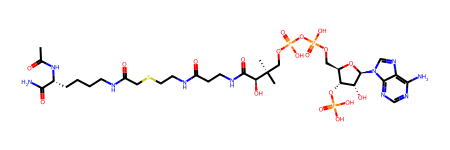

正在处理 Data/bh/7bh9_0_NAG_ligand.pdb
从 PDB 文件加载的分子包含 14 个原子
匹配失败，可能是由于原子数目或元素不匹配: No matching found
无法创建分子对象 for Data/bh/7bh9_0_NAG_ligand.pdb，跳过该文件 CC(=O)N[CH]1[CH](O)O[CH](CO)[CH](O)[CH]1O
正在处理 Data/bh/6bhy_1_NAG_ligand.pdb
从 PDB 文件加载的分子包含 14 个原子
匹配失败，可能是由于原子数目或元素不匹配: No matching found
无法创建分子对象 for Data/bh/6bhy_1_NAG_ligand.pdb，跳过该文件 CC(=O)N[CH]1[CH](O)O[CH](CO)[CH](O)[CH]1O
正在处理 Data/bh/8bhh_7_P6G_ligand.pdb
从 PDB 文件加载的分子包含 19 个原子


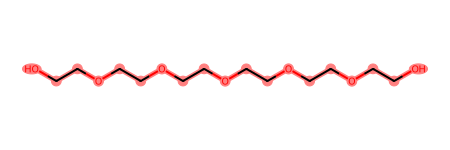

正在处理 Data/bh/8bhg_10_QMU_ligand.pdb
从 PDB 文件加载的分子包含 46 个原子
匹配失败，可能是由于原子数目或元素不匹配: Explicit valence for atom # 13 C, 5, is greater than permitted
无法创建分子对象 for Data/bh/8bhg_10_QMU_ligand.pdb，跳过该文件 CC(C)(C)OC(=O)c1ncn2c3cccc(Br)c3C(=O)N4CCC[CH]4c12
正在处理 Data/bh/4bhf_2_16D_ligand.pdb
从 PDB 文件加载的分子包含 8 个原子


[13:26:37] WARNING: More than one matching pattern found - picking one

[13:26:37] Explicit valence for atom # 13 C, 5, is greater than permitted


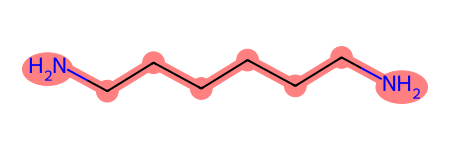

正在处理 Data/bh/7bhw_1_SAM_ligand.pdb
从 PDB 文件加载的分子包含 27 个原子


[13:26:37] WARNING: More than one matching pattern found - picking one



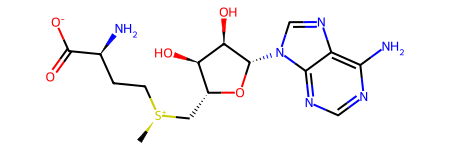

正在处理 Data/bh/3bhm_2_AB3_ligand.pdb
从 PDB 文件加载的分子包含 21 个原子


[13:26:37] WARNING: More than one matching pattern found - picking one



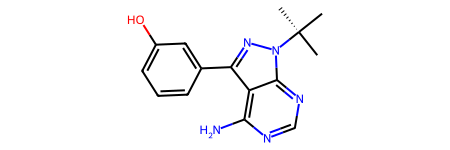

正在处理 Data/bh/2bhw_40_CLA_ligand.pdb
从 PDB 文件加载的分子包含 59 个原子
匹配失败，可能是由于原子数目或元素不匹配: No matching found
无法创建分子对象 for Data/bh/2bhw_40_CLA_ligand.pdb，跳过该文件 CCC1=C(C)C2=Cc3n4[Mg][N]5C(=CC1=N2)C(=C6C(=O)[CH](C(=O)OC)C(=C56)C7=NC(=Cc4c(C)c3C=C)[CH](C)[CH]7CCC(=O)OCC=C(C)CCC[CH](C)CCC[CH](C)CCCC(C)C)C
正在处理 Data/bh/6bh0_0_DO1_ligand.pdb
从 PDB 文件加载的分子包含 29 个原子


[13:26:37] WARNING: More than one matching pattern found - picking one



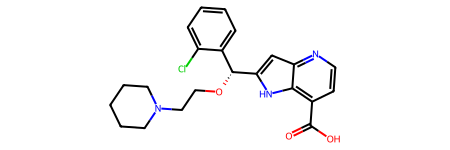

正在处理 Data/bh/6bh2_7_EDO_ligand.pdb
从 PDB 文件加载的分子包含 4 个原子


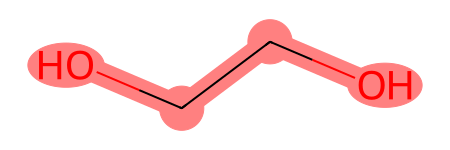

正在处理 Data/bh/2bhw_78_CLA_ligand.pdb
从 PDB 文件加载的分子包含 64 个原子
匹配失败，可能是由于原子数目或元素不匹配: No matching found
无法创建分子对象 for Data/bh/2bhw_78_CLA_ligand.pdb，跳过该文件 CCC1=C(C)C2=Cc3n4[Mg][N]5C(=CC1=N2)C(=C6C(=O)[CH](C(=O)OC)C(=C56)C7=NC(=Cc4c(C)c3C=C)[CH](C)[CH]7CCC(=O)OCC=C(C)CCC[CH](C)CCC[CH](C)CCCC(C)C)C
正在处理 Data/bh/2bhw_41_CLA_ligand.pdb
从 PDB 文件加载的分子包含 1 个原子
匹配失败，可能是由于原子数目或元素不匹配: No matching found
无法创建分子对象 for Data/bh/2bhw_41_CLA_ligand.pdb，跳过该文件 CCC1=C(C)C2=Cc3n4[Mg][N]5C(=CC1=N2)C(=C6C(=O)[CH](C(=O)OC)C(=C56)C7=NC(=Cc4c(C)c3C=C)[CH](C)[CH]7CCC(=O)OCC=C(C)CCC[CH](C)CCC[CH](C)CCCC(C)C)C
正在处理 Data/bh/2bhw_82_CLA_ligand.pdb
从 PDB 文件加载的分子包含 56 个原子
匹配失败，可能是由于原子数目或元素不匹配: No matching found
无法创建分子对象 for Data/bh/2bhw_82_CLA_ligand.pdb，跳过该文件 CCC1=C(C)C2=Cc3n4[Mg][N]5C(=CC1=N2)C(=C6C(=O)[CH](C(=O)OC)C(=C56)C7=NC(=Cc4c(C)c3C=C)[CH](C)[CH]7CCC(=O)OCC=C(C)CCC[CH](C)CCC[CH](C)CCCC(C)C)C
正在处理 Data/bh/3bhb_0_EDO_ligand.pdb
从 PDB 文件加载的分子包含 4 个原子


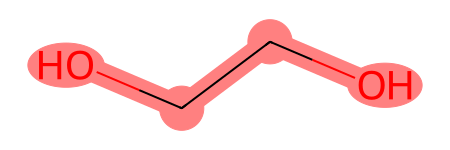

正在处理 Data/bh/2bhq_8_MRD_ligand.pdb
从 PDB 文件加载的分子包含 8 个原子


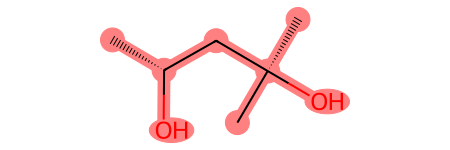

正在处理 Data/bh/2bhw_71_XAT_ligand.pdb
从 PDB 文件加载的分子包含 44 个原子


[13:26:37] WARNING: More than one matching pattern found - picking one



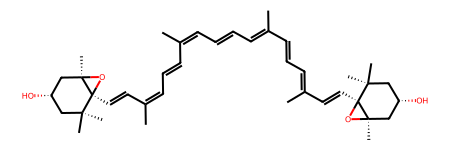

正在处理 Data/bh/4bh0_5_GAL_ligand.pdb
从 PDB 文件加载的分子包含 46 个原子


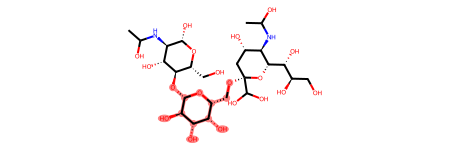

正在处理 Data/bh/2bhb_1_MRD_ligand.pdb
从 PDB 文件加载的分子包含 8 个原子


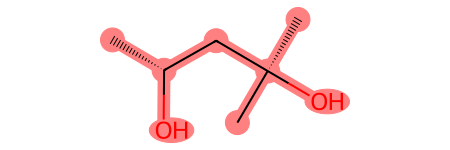

[13:26:37] WARNING: More than one matching pattern found - picking one



正在处理 Data/bh/8bhi_7_QKF_ligand.pdb
从 PDB 文件加载的分子包含 53 个原子


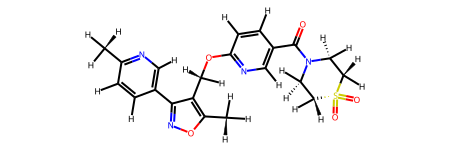

In [ ]:
import glob

lig_pdbFile_list = glob.glob('Data/*/*_ligand.pdb')  # 获取所有小分子 PDB 文件的路径列表
for ilig in lig_pdbFile_list[:20]:  # 仅处理前 10 个文件以节省时间
    print(f"正在处理 {ilig}")
    cpd_id_list = get_residue_names(ilig)  # 从 PDB 文件中提取残留基名称列表
    cpd_id = cpd_id_list[0] if len(cpd_id_list) > 0 else None  # 假设每个 PDB 文件只包含一个小分子残留基
    if cpd_id not in df_cpd_id.index:
        print(f"在 DataFrame 中未找到 {cpd_id} 的 SMILES，跳过 {ilig}")
        continue
    
    smi = df_cpd_id.loc[cpd_id, 'smiles']  # 根据提取的残留基名称在 DataFrame 中查找对应的 SMILES
    mol = create_correct_mol(ilig, smi)  # 使用 SMILES 模板修正 PDB 分子的键级信息
    if mol is None:
        print(f"无法创建分子对象 for {ilig}，跳过该文件 {smi}")
        continue
    
    AllChem.Compute2DCoords(mol)  # 计算 2D 坐标以便可视化
    display(mol)  # 显示分子结构







